In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Change "1" to the desired GPU index
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"  # Use 50% of GPU memory
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

from jaxili.inference import NPE

# device = jax.devices("gpu")[0] 
print("Device used by jax:", jax.devices())

# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform" # Avoids preallocation of GPU memory

Device used by jax: [CudaDevice(id=0)]


In [2]:
params = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_params_baryonified.npy', allow_pickle=True)

# **BIN 2**

In [5]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_baryonified_bin2_noisy_s0.26.npy', allow_pickle=True)

In [6]:
params.shape, l1_full.shape

((16966, 6), (16966, 5, 40))

## Scale 1

In [7]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16966, 40)

In [8]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [9]:
dataset = (params, l1_scale1)

In [10]:
inference = NPE()

In [11]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [12]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin2_scale1_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -6.674/ Best val loss -6.675:  47%|████▋     | 472/1000 [03:35<04:00,  2.19it/s]


Neural network training stopped after 473 epochs.
Early stopping with best validation metric: -6.674950122833252
Best model saved at epoch 460
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -6.749029159545898
[!] Validation loss: -6.675309181213379
[!] Test loss: -6.450353622436523


In [13]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [25]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin2_noisy_s0.26.npy', allow_pickle=True)

In [26]:
np.array(fid_full).shape

(200, 5, 40)

In [27]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [28]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [29]:
import jax.random as random

master_key = random.PRNGKey(1)

In [30]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [31]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [32]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


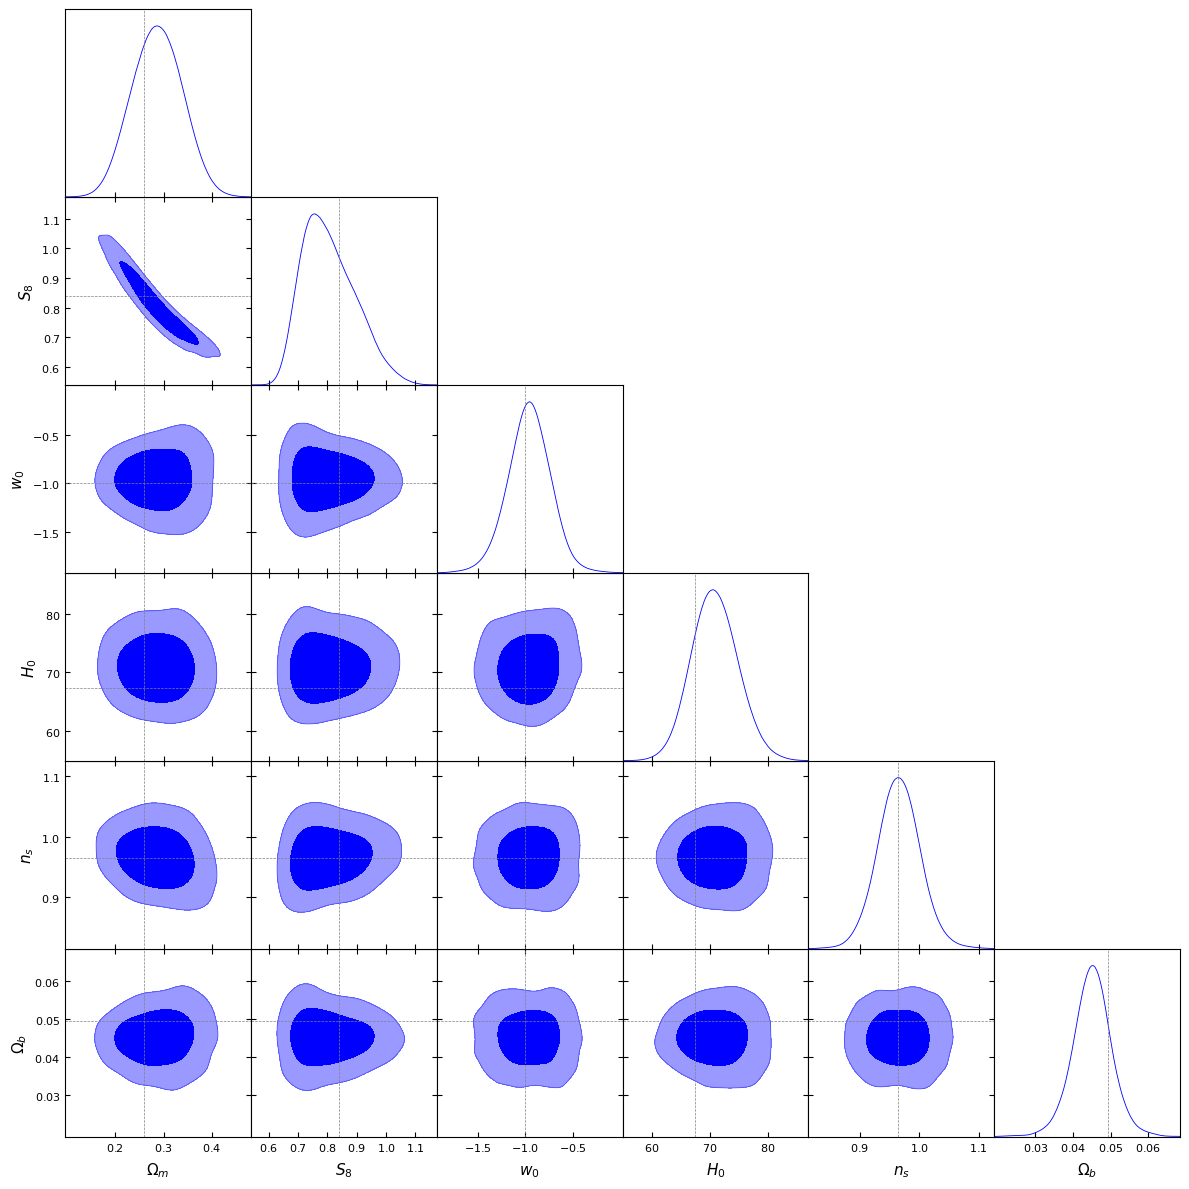

In [35]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin2_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin2, scale1",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin2_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [36]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin2_noisy_s026_npe.npy", samples_nobar_bin2_scale1.samples)

## Scale 2

In [37]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16966, 40)

In [38]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)

In [39]:
dataset = (params, l1_scale2)

In [40]:
inference = NPE()

In [41]:
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [42]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin2_scale2_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size=40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.553/ Best val loss -7.552:  48%|████▊     | 478/1000 [02:41<02:56,  2.96it/s]


Neural network training stopped after 479 epochs.
Early stopping with best validation metric: -7.551809787750244
Best model saved at epoch 478
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -7.585855007171631
[!] Validation loss: -7.552668571472168
[!] Test loss: -7.567764759063721


In [43]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [44]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin2_noisy_s0.26.npy', allow_pickle=True)

In [45]:
np.array(fid_full).shape

(200, 5, 40)

In [46]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [47]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [48]:
import jax.random as random

master_key = random.PRNGKey(1)

In [50]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [51]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [52]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


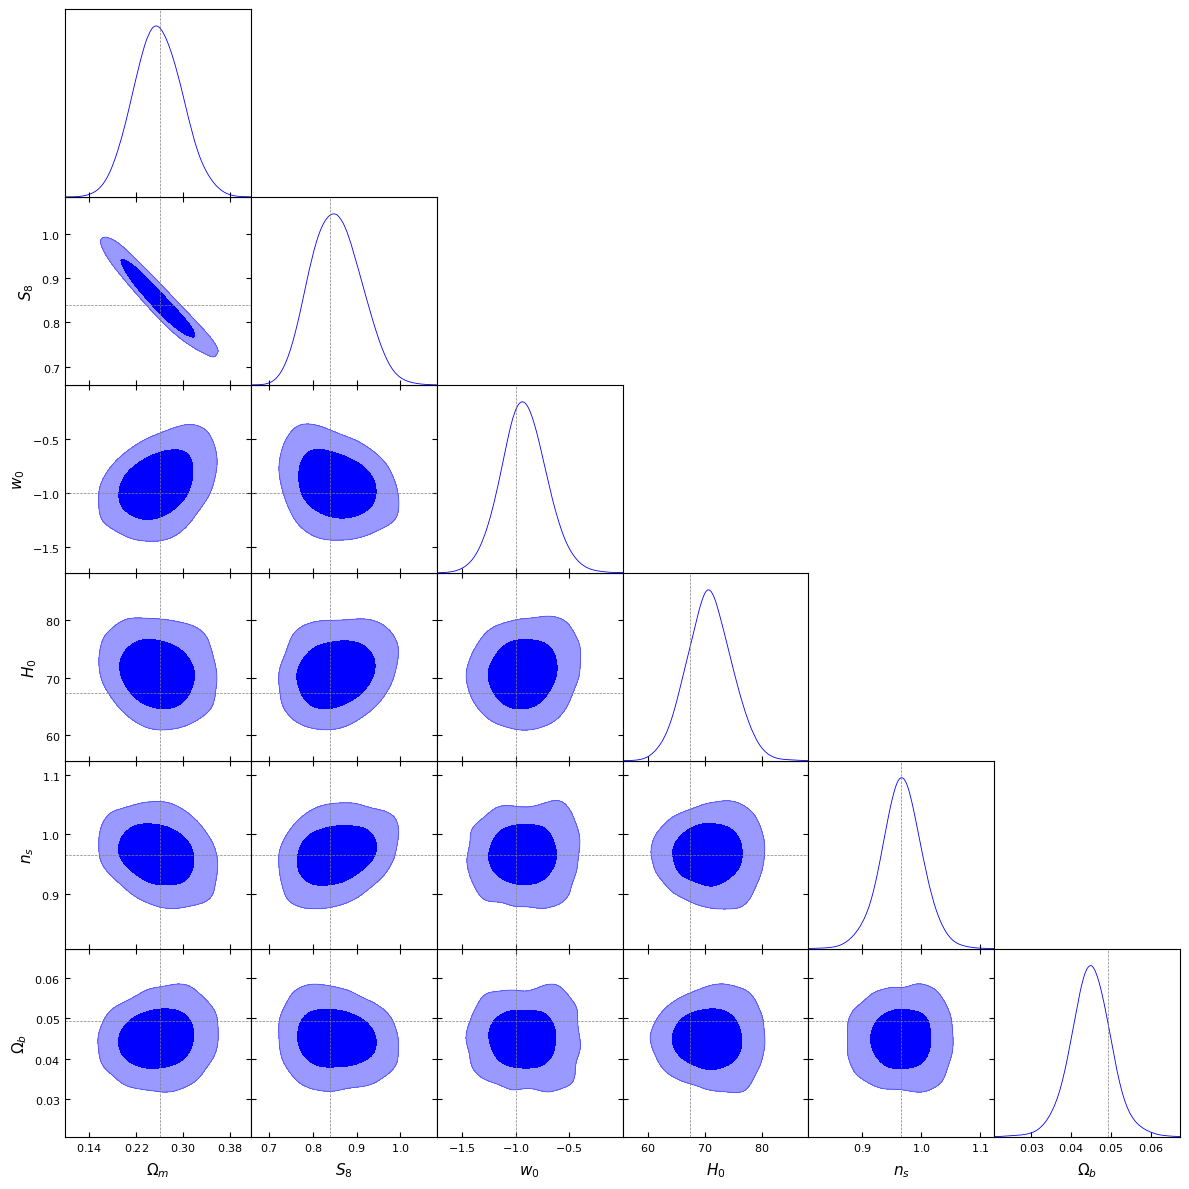

In [53]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin2_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin2, scale2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin2_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [54]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin2_noisy_s026_npe.npy", samples_nobar_bin2_scale2.samples)

# **BIN 3**

In [8]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_baryonified_bin3_noisy_s0.26.npy', allow_pickle=True)

In [9]:
params.shape, l1_full.shape

((16966, 6), (16966, 5, 40))

## Scale 1

In [10]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16966, 40)

In [11]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [12]:
dataset = (params, l1_scale1)

In [13]:
inference = NPE()

In [14]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [15]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin3_scale1_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -7.244/ Best val loss -7.243:  49%|████▉     | 489/1000 [02:47<02:55,  2.92it/s]


Neural network training stopped after 490 epochs.
Early stopping with best validation metric: -7.24299955368042
Best model saved at epoch 490
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -7.3049516677856445
[!] Validation loss: -7.243728160858154
[!] Test loss: -7.2853169441223145


In [16]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [17]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin3_noisy_s0.26.npy', allow_pickle=True)

In [18]:
np.array(fid_full).shape

(200, 5, 40)

In [19]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [20]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [21]:
import jax.random as random

master_key = random.PRNGKey(1)

In [22]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [23]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [24]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


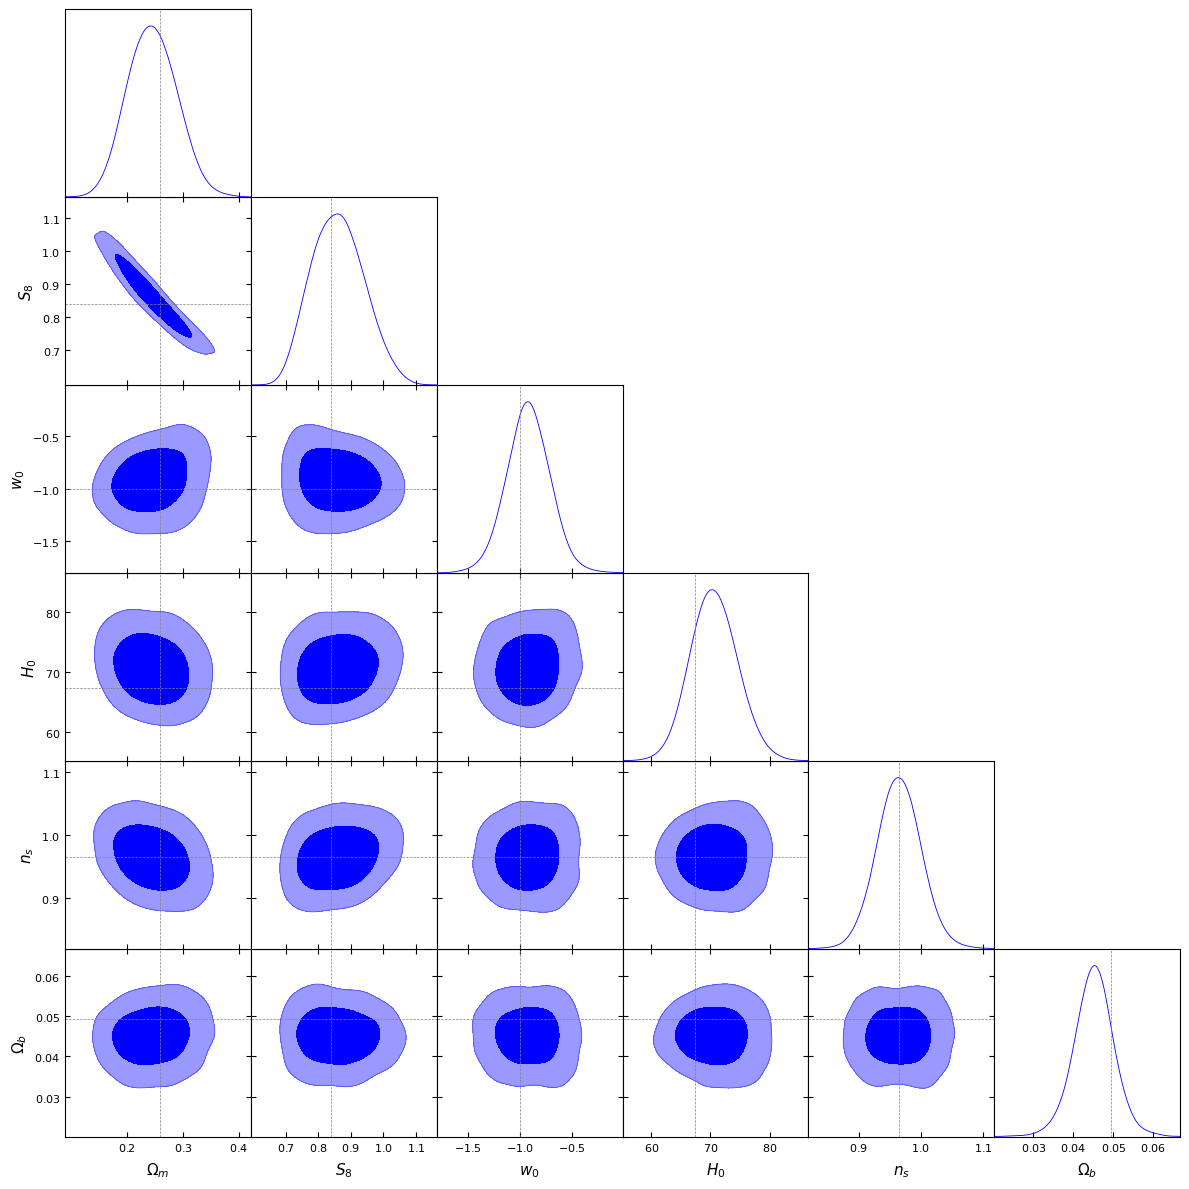

In [28]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin3_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin3, scale1",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin3_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [29]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin3_noisy_s026_npe.npy", samples_nobar_bin3_scale1.samples)

## Scale 2

In [27]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16966, 40)

In [30]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)

In [31]:
dataset = (params, l1_scale2)

In [32]:
inference = NPE()

In [33]:
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [34]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin3_scale2_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size=40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -7.731/ Best val loss -7.730:  49%|████▉     | 489/1000 [02:49<02:57,  2.88it/s]


Neural network training stopped after 490 epochs.
Early stopping with best validation metric: -7.730306148529053
Best model saved at epoch 487
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -7.764776229858398
[!] Validation loss: -7.731163024902344
[!] Test loss: -7.760301113128662


In [35]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [36]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin3_noisy_s0.26.npy', allow_pickle=True)

In [37]:
np.array(fid_full).shape

(200, 5, 40)

In [38]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [39]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [40]:
import jax.random as random

master_key = random.PRNGKey(1)

In [41]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [42]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [43]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


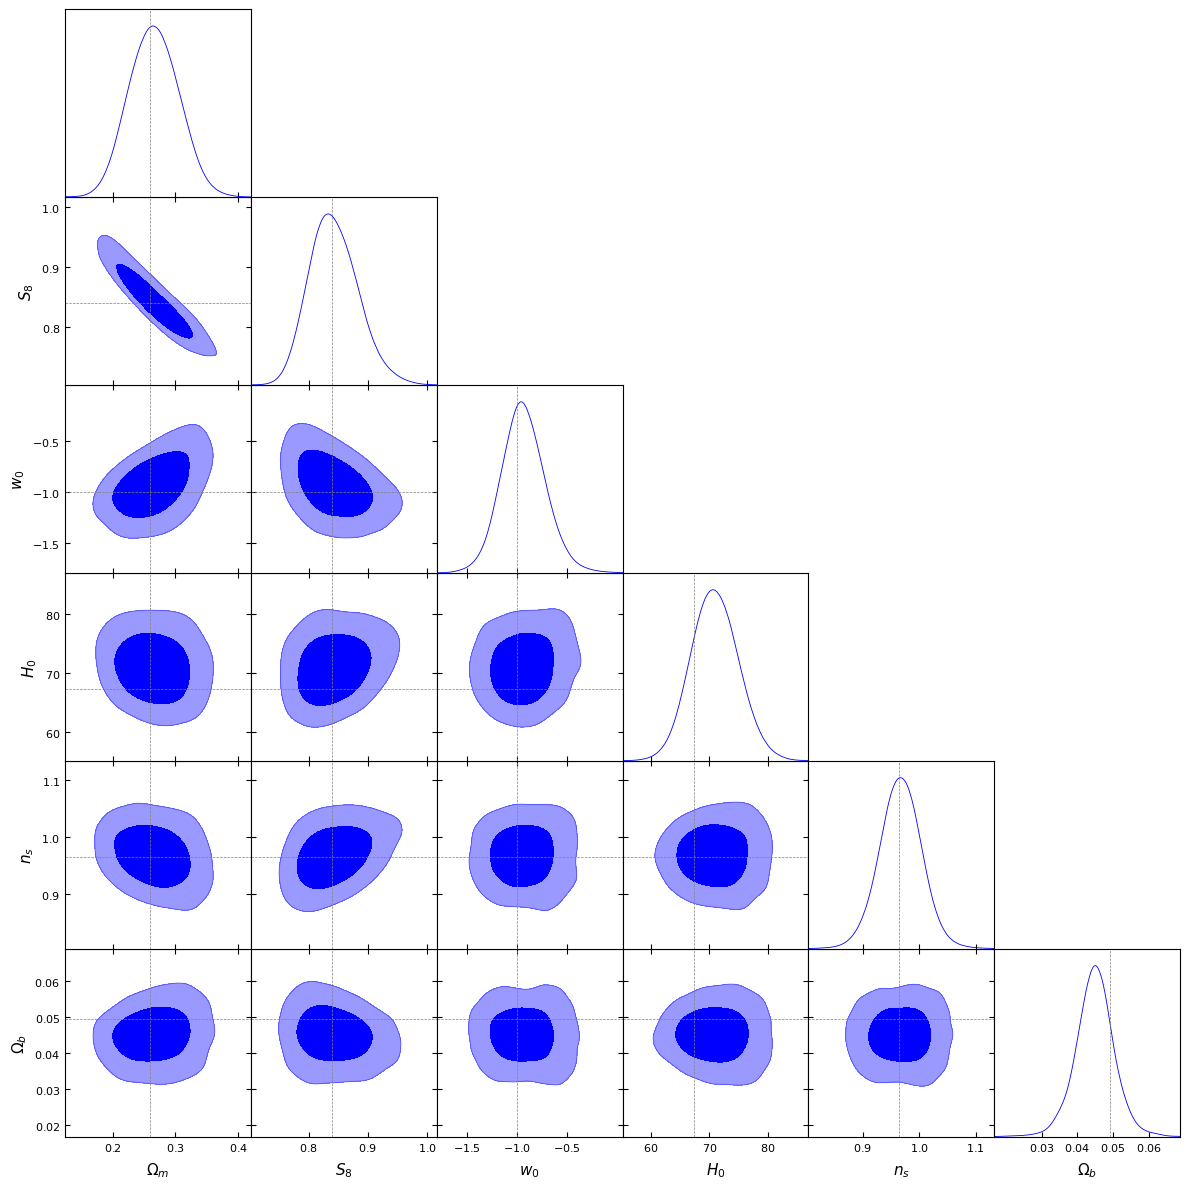

In [44]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin3_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin3, scale2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin3_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [48]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin3_noisy_s026_npe.npy", samples_nobar_bin3_scale2.samples)

# **BIN 4**

## NoBar training data vs Bar fid obs

In [3]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_baryonified_bin4_noisy_s0.26.npy', allow_pickle=True)

In [4]:
params.shape, l1_full.shape

((16966, 6), (16966, 5, 40))

## Scale 1

In [5]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16966, 40)

In [6]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [7]:
dataset = (params, l1_scale1)

In [8]:
inference = NPE()

In [9]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [10]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin4_scale1_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.


[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -7.490/ Best val loss -7.492:  46%|████▌     | 457/1000 [02:30<02:59,  3.03it/s]


Neural network training stopped after 458 epochs.
Early stopping with best validation metric: -7.4916510581970215
Best model saved at epoch 437
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -7.478899955749512
[!] Validation loss: -7.4916510581970215
[!] Test loss: -7.418185234069824


In [11]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [12]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin4_noisy_s0.26.npy', allow_pickle=True)

In [13]:
np.array(fid_full).shape

(200, 5, 40)

In [14]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [15]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [16]:
import jax.random as random

master_key = random.PRNGKey(1)

In [17]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [18]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [19]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


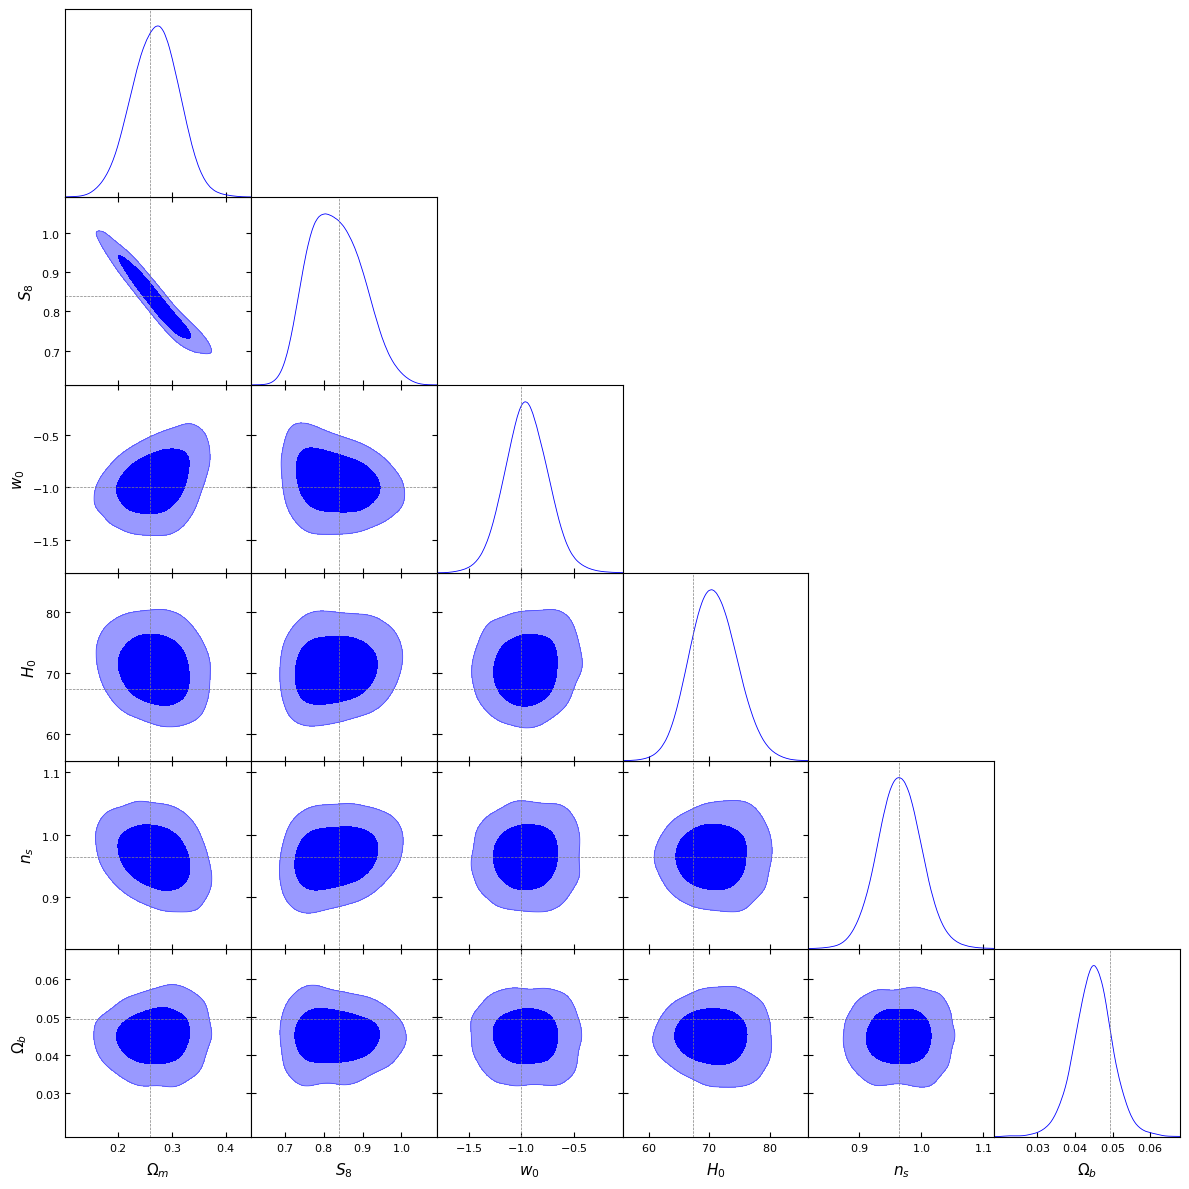

In [20]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin4_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin4, scale1",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin4_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [21]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin4_noisy_s026_npe.npy", samples_nobar_bin4_scale1.samples)

## Scale 2

In [22]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16966, 40)

In [23]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)

In [24]:
dataset = (params, l1_scale2)

In [25]:
inference = NPE()

In [26]:
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [27]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin4_scale2_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size=40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.597/ Best val loss -7.596:  50%|████▉     | 495/1000 [02:48<02:52,  2.93it/s]


Neural network training stopped after 496 epochs.
Early stopping with best validation metric: -7.5963544845581055
Best model saved at epoch 496
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -7.611098766326904
[!] Validation loss: -7.597059726715088
[!] Test loss: -7.606496810913086


In [28]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [29]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin4_noisy_s0.26.npy', allow_pickle=True)

In [30]:
np.array(fid_full).shape

(200, 5, 40)

In [31]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [32]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [33]:
import jax.random as random

master_key = random.PRNGKey(1)

In [34]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [35]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [36]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


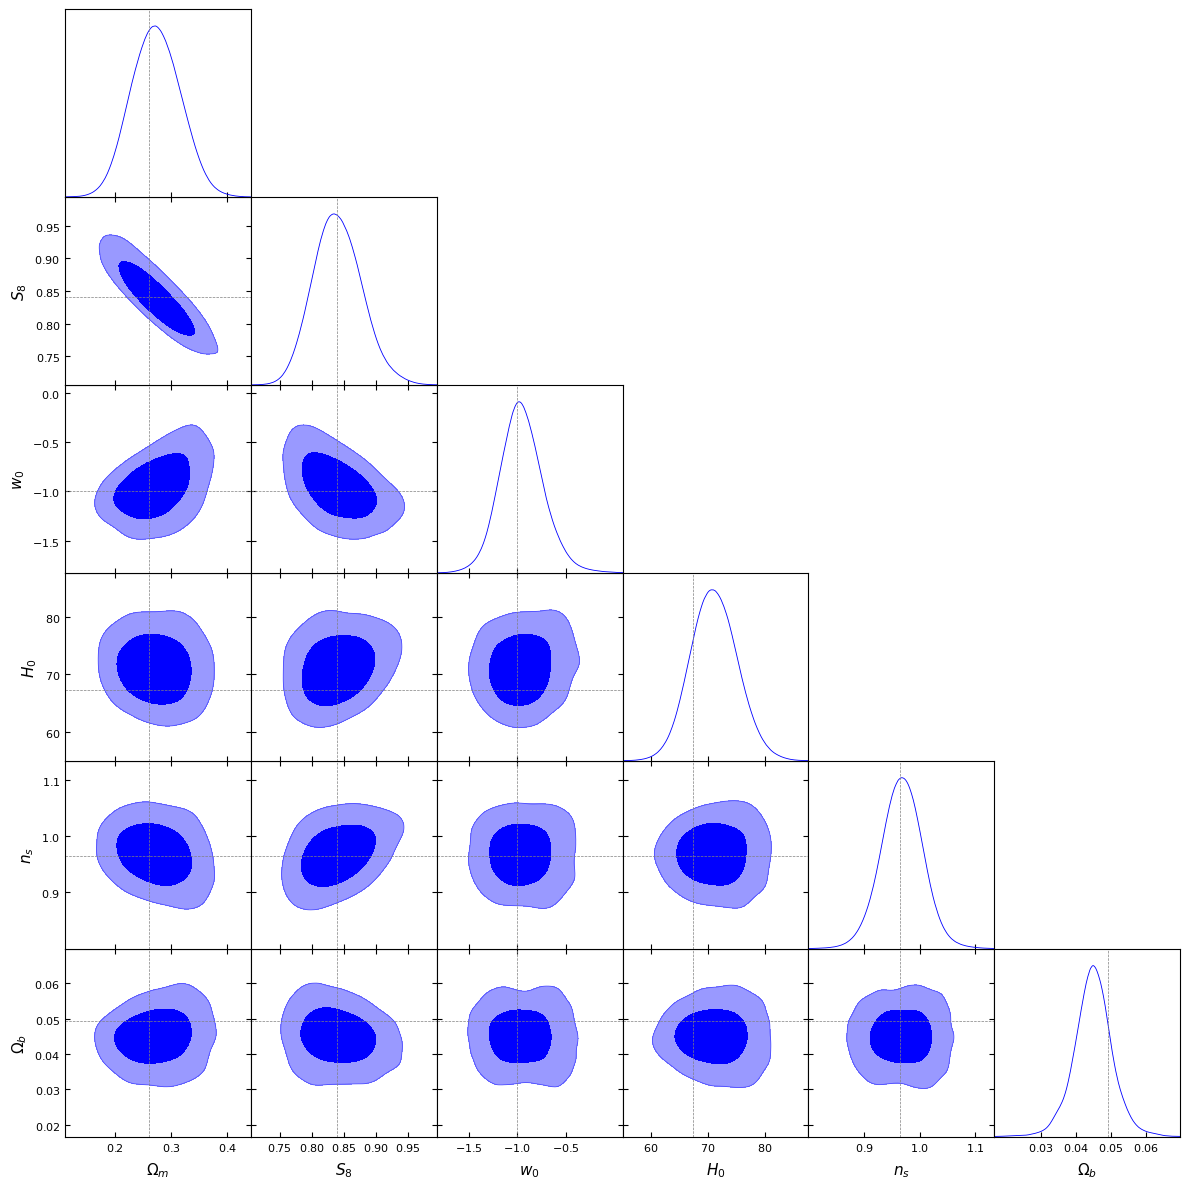

In [37]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin4_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin4, scale2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin4_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [38]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin4_noisy_s026_npe.npy", samples_nobar_bin4_scale2.samples)

# Compare Bins

## Scale 1

In [39]:
samples_bar_bin1_scale1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin2_scale1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin2_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin3_scale1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin3_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin4_scale1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin4_noisy_s026_npe.npy", allow_pickle=True)

In [40]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale1 = MCSamples(
    samples=samples_bar_bin1_scale1,
    names=labels,
    label="Bar, bin1, scale1",
)
samples_nobar_bin2_scale1 = MCSamples(
    samples=samples_bar_bin2_scale1,
    names=labels,
    label="Bar, bin2, scale1",
)
samples_nobar_bin3_scale1 = MCSamples(
    samples=samples_bar_bin3_scale1,
    names=labels,
    label="Bar, bin3, scale1",
)
samples_nobar_bin4_scale1 = MCSamples(
    samples=samples_bar_bin4_scale1,
    names=labels,
    label="Bar, bin4, scale1",
)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


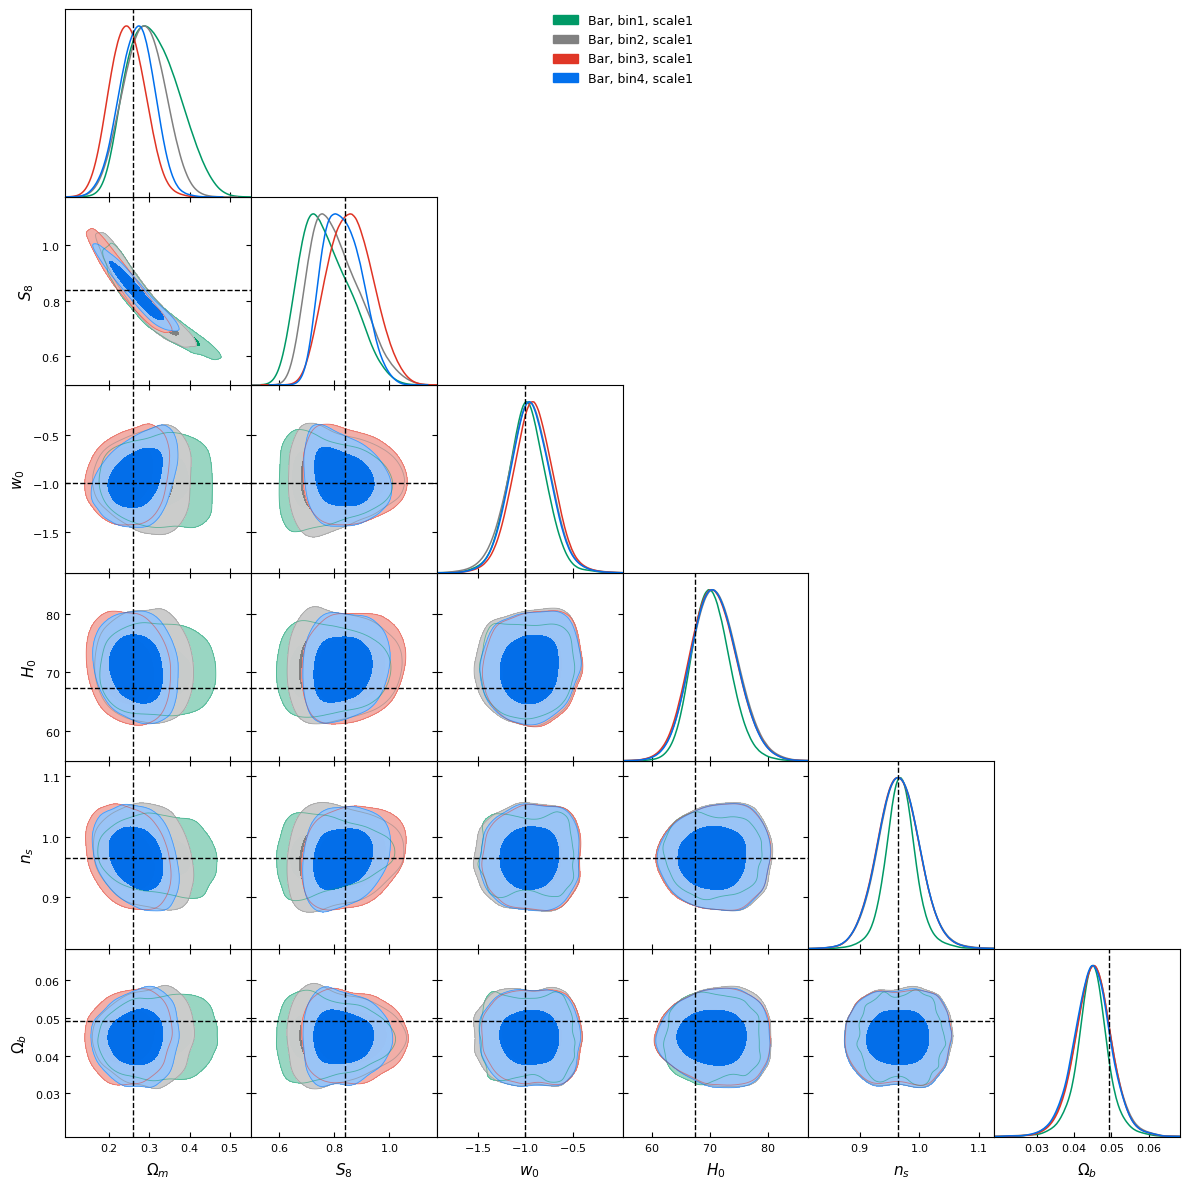

In [41]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_nobar_bin1_scale1, samples_nobar_bin2_scale1, samples_nobar_bin3_scale1, samples_nobar_bin4_scale1],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_scale1_different_bins_npe.pdf", transparent=True)
plt.show()

## Scale 2

In [43]:
samples_bar_bin1_scale2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin2_scale2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin2_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin3_scale2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin3_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin4_scale2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin4_noisy_s026_npe.npy", allow_pickle=True)

In [44]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale2 = MCSamples(
    samples=samples_bar_bin1_scale2,
    names=labels,
    label="Bar, bin1, scale2",
)
samples_nobar_bin2_scale2 = MCSamples(
    samples=samples_bar_bin2_scale2,
    names=labels,
    label="Bar, bin2, scale2",
)
samples_nobar_bin3_scale2 = MCSamples(
    samples=samples_bar_bin3_scale2,
    names=labels,
    label="Bar, bin3, scale2",
)
samples_nobar_bin4_scale2 = MCSamples(
    samples=samples_bar_bin4_scale2,
    names=labels,
    label="Bar, bin4, scale2",
)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


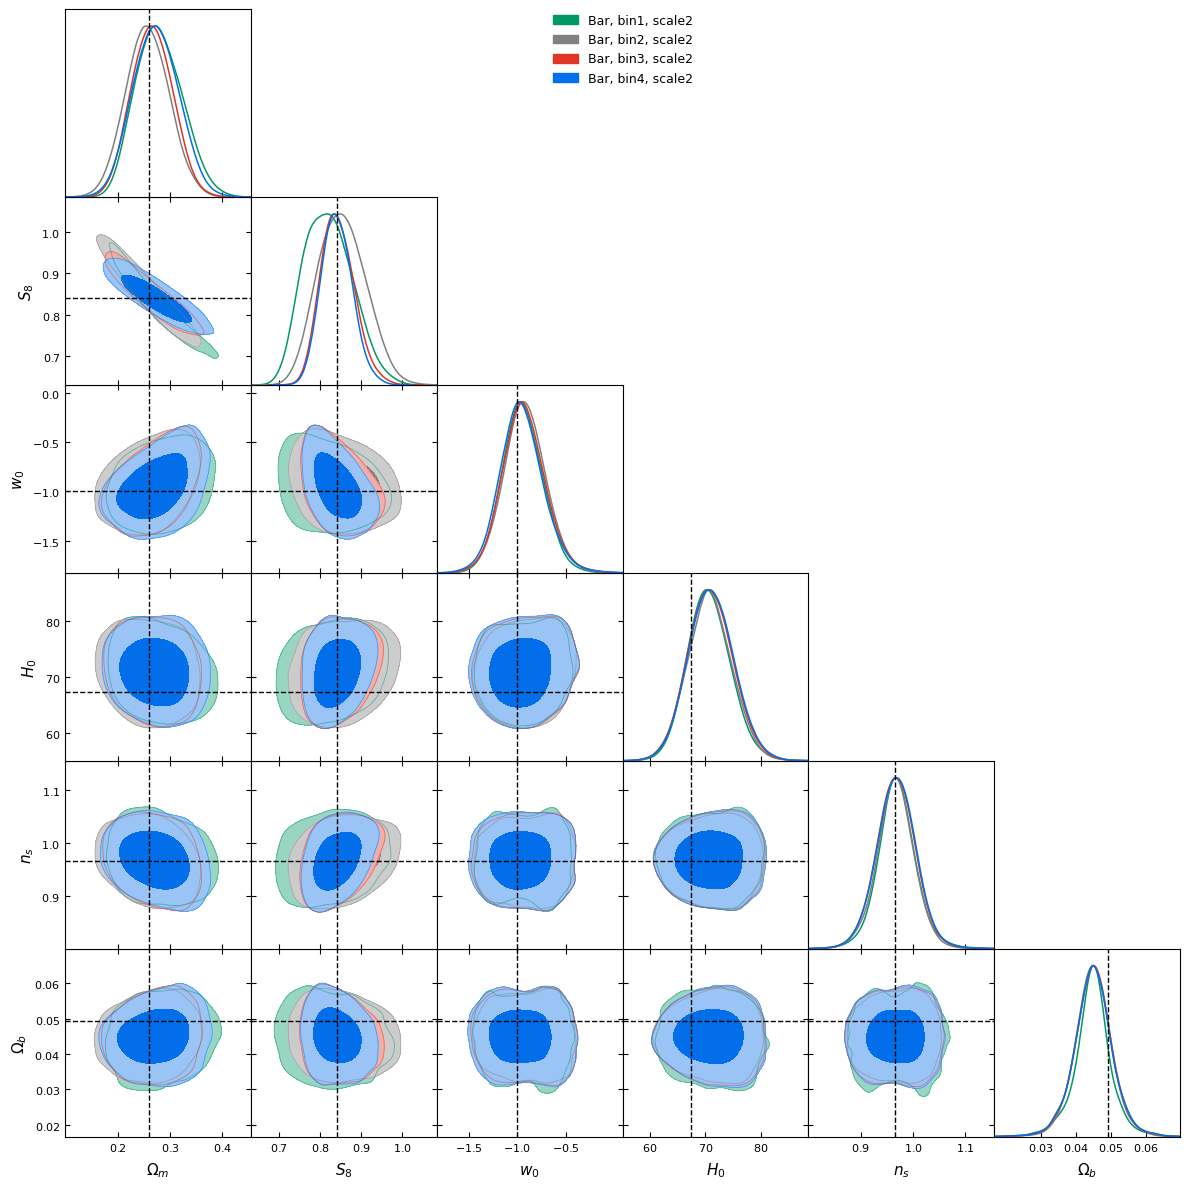

In [45]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_nobar_bin1_scale2, samples_nobar_bin2_scale2, samples_nobar_bin3_scale2, samples_nobar_bin4_scale2],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_scale2_different_bins_npe.pdf", transparent=True)
plt.show()

# Compare scales 1&2 for each bin

In [46]:
samples_bar_bin1_scale1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin1_scale2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin2_scale1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin2_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin2_scale2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin2_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin3_scale1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin3_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin3_scale2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin3_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin4_scale1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin4_noisy_s026_npe.npy", allow_pickle=True)
samples_bar_bin4_scale2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin4_noisy_s026_npe.npy", allow_pickle=True)

## Bin 1

In [ ]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale1 = MCSamples(
    samples=samples_bar_bin1_scale1,
    names=labels,
    label="Bar, bin1, scale1",
)
samples_nobar_bin1_scale2 = MCSamples(
    samples=samples_bar_bin1_scale2,
    names=labels,
    label="Bar, bin1, scale2",
)

Removed no burn in
Removed no burn in


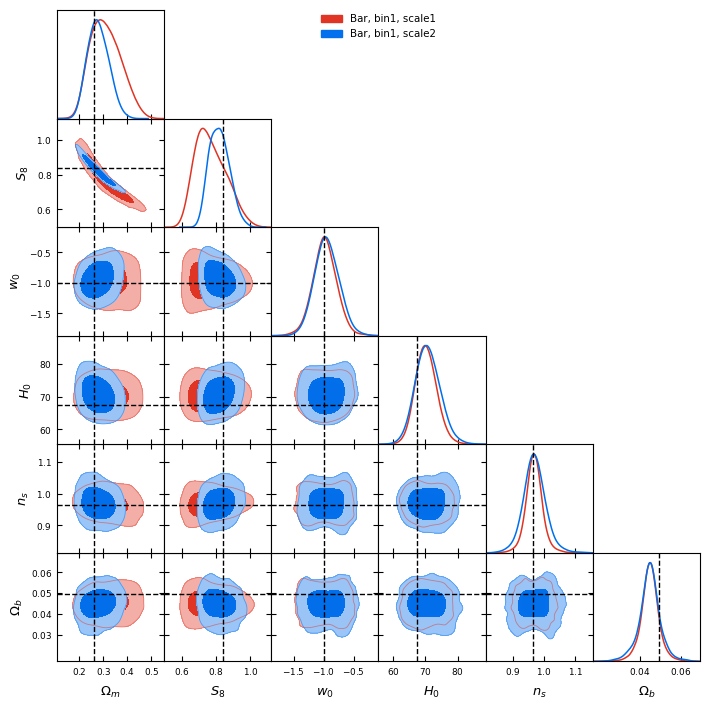

In [54]:
g = plots.get_subplot_plotter(subplot_size=1.2)

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_nobar_bin1_scale1, samples_nobar_bin1_scale2],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
# plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_scale2_different_bins_npe.pdf", transparent=True)
plt.show()

## Bin 2

In [55]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin2_scale1 = MCSamples(
    samples=samples_bar_bin2_scale1,
    names=labels,
    label="Bar, bin2, scale1",
)
samples_nobar_bin2_scale2 = MCSamples(
    samples=samples_bar_bin2_scale2,
    names=labels,
    label="Bar, bin2, scale2",
)

Removed no burn in
Removed no burn in


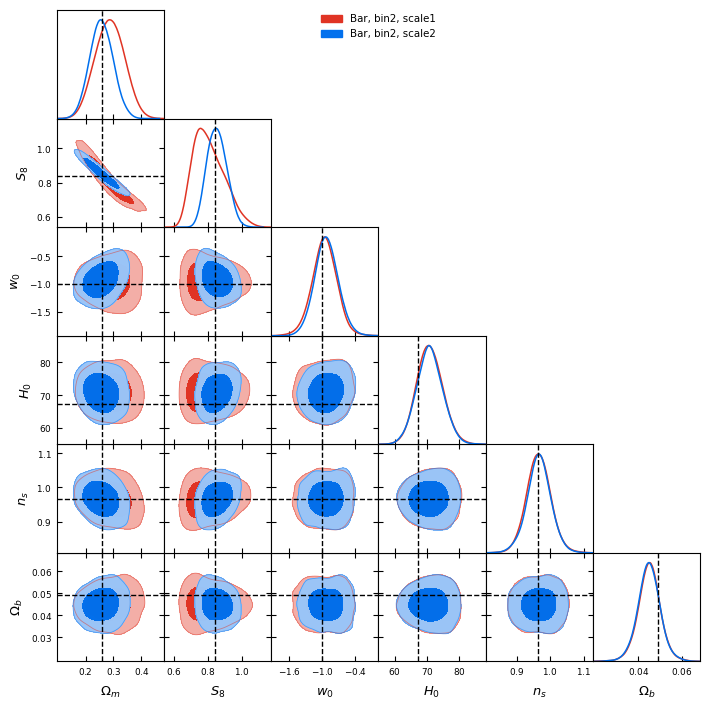

In [56]:
g = plots.get_subplot_plotter(subplot_size=1.2)

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_nobar_bin2_scale1, samples_nobar_bin2_scale2],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
# plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_scale2_different_bins_npe.pdf", transparent=True)
plt.show()

## Bin 3

In [57]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin3_scale1 = MCSamples(
    samples=samples_bar_bin3_scale1,
    names=labels,
    label="Bar, bin3, scale1",
)
samples_nobar_bin3_scale2 = MCSamples(
    samples=samples_bar_bin3_scale2,
    names=labels,
    label="Bar, bin3, scale2",
)

Removed no burn in
Removed no burn in


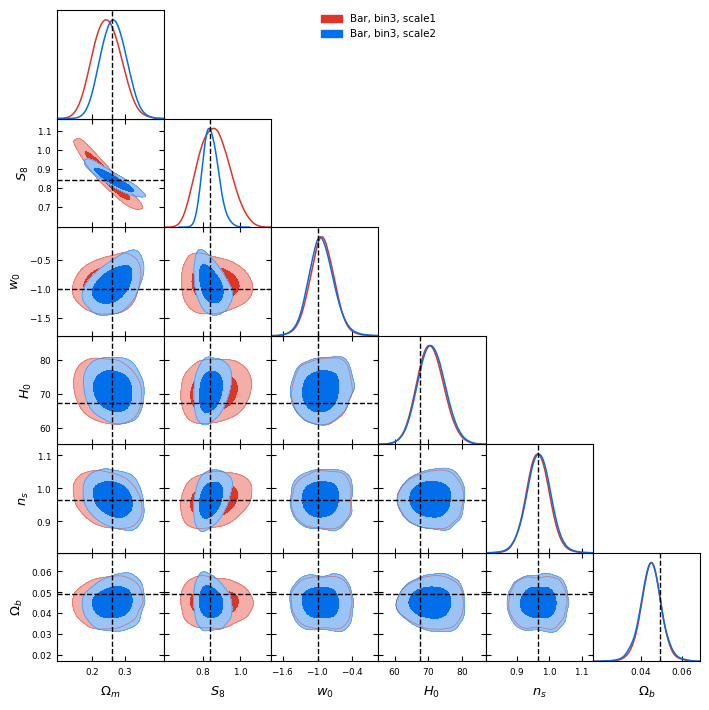

In [58]:
g = plots.get_subplot_plotter(subplot_size=1.2)

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_nobar_bin3_scale1, samples_nobar_bin3_scale2],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
# plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_scale2_different_bins_npe.pdf", transparent=True)
plt.show()

## Bin 4

In [59]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin4_scale1 = MCSamples(
    samples=samples_bar_bin4_scale1,
    names=labels,
    label="Bar, bin4, scale1",
)
samples_nobar_bin4_scale2 = MCSamples(
    samples=samples_bar_bin4_scale2,
    names=labels,
    label="Bar, bin4, scale2",
)

Removed no burn in
Removed no burn in


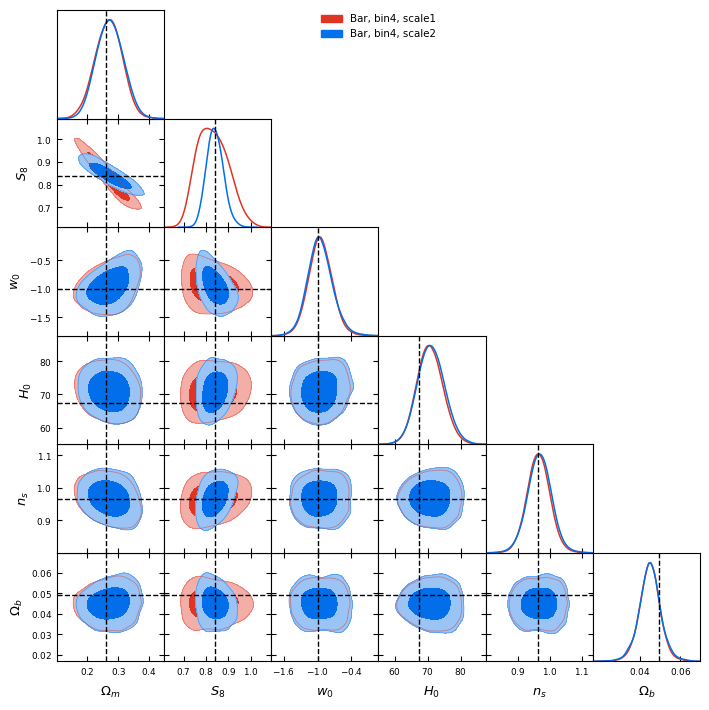

In [60]:
g = plots.get_subplot_plotter(subplot_size=1.2)

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_nobar_bin4_scale1, samples_nobar_bin4_scale2],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
# plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_scale2_different_bins_npe.pdf", transparent=True)
plt.show()

In [ ]:
samples_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale1_bin1_noisy_s026_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [ ]:
samples_bar = MCSamples(
    samples=samples_bar,
    names=labels,
    label="Bar, bin1, scale1, noisy",
)
samples_nobar = MCSamples(
    samples=samples_nobar,
    names=labels,
    label="NoBar, bin1, scale1, noisy",
)

Removed no burn in
Removed no burn in


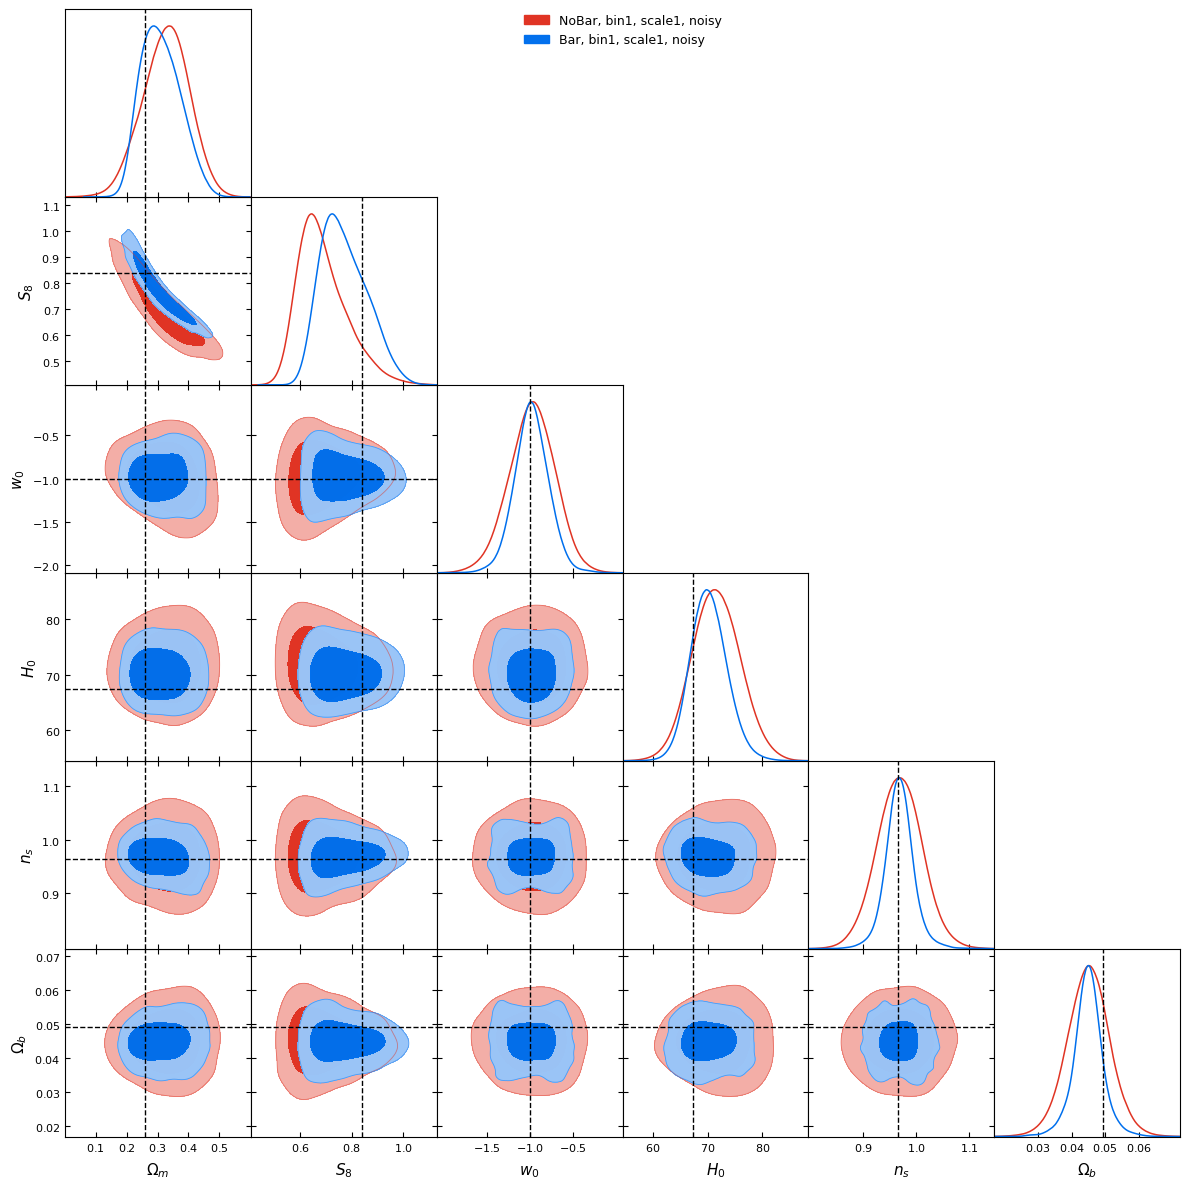

In [ ]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_nobar, samples_bar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_vs_NoBar_biased_bin1_scale1_npe.pdf")
plt.show()

## Scale 2

In [ ]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16965, 40)

In [ ]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)

In [ ]:
dataset = (params, l1_scale2)

In [ ]:
inference = NPE()

In [ ]:
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [ ]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale2_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.488/ Best val loss -7.500:  15%|█▍        | 148/1000 [01:03<06:05,  2.33it/s]

Neural network training stopped after 149 epochs.
Early stopping with best validation metric: -7.499804973602295
Best model saved at epoch 146
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.607852935791016
[!] Validation loss: -7.50037145614624
[!] Test loss: -7.542699813842773


In [ ]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [ ]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_baryonified_fid_bin1_noisy_s026.npy', allow_pickle=True)

In [ ]:
np.array(fid_full).shape

(200, 5, 40)

In [ ]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [ ]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [ ]:
import jax.random as random

master_key = random.PRNGKey(1)

In [ ]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [ ]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [ ]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


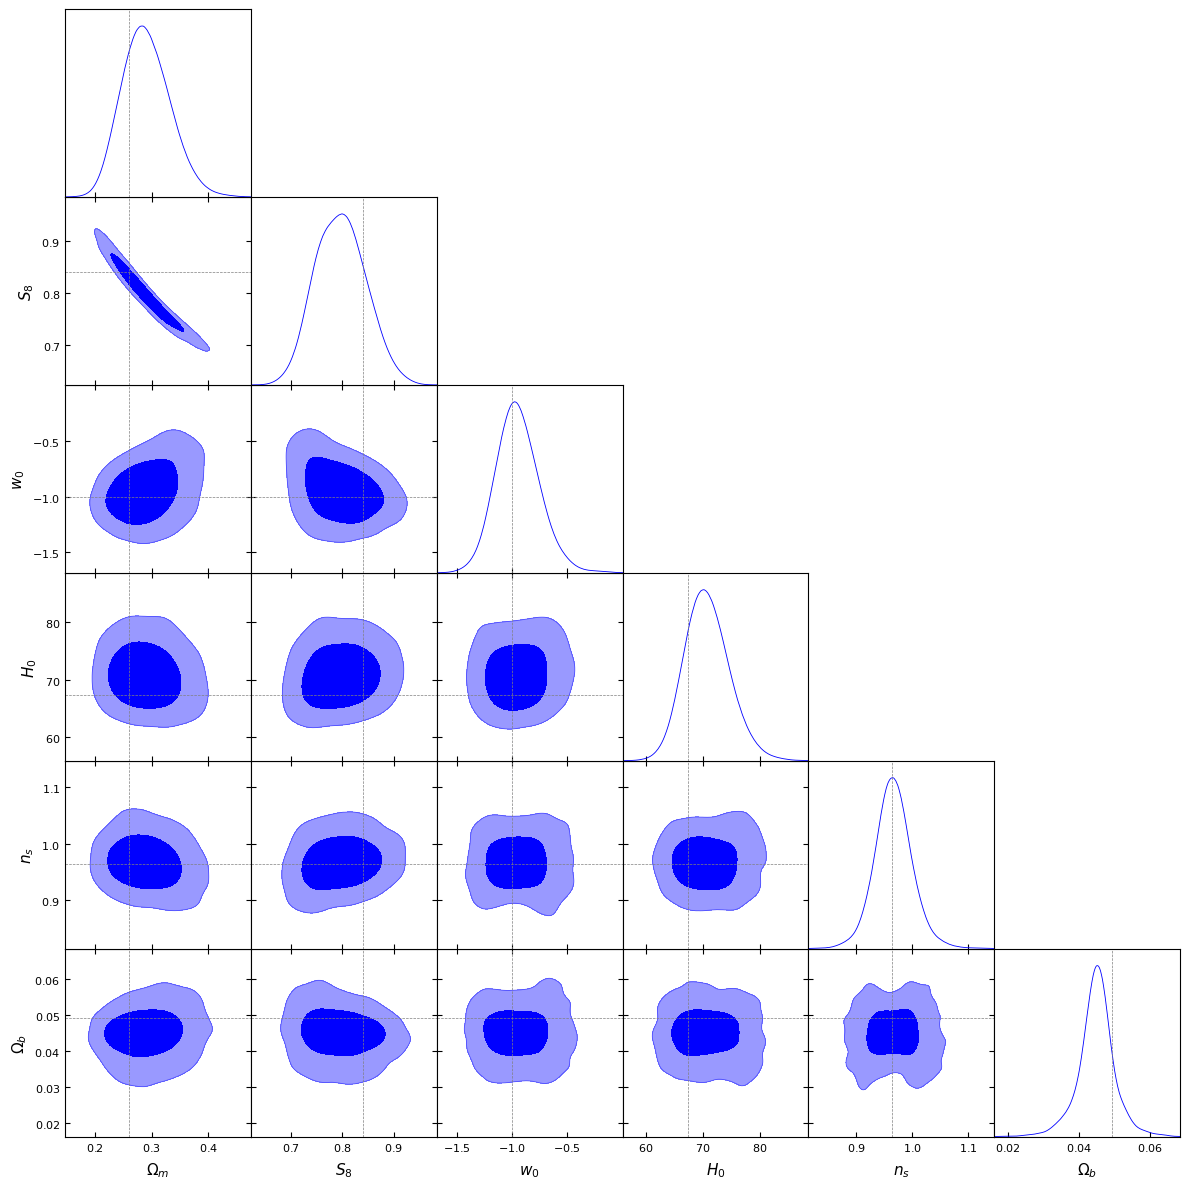

In [ ]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="NoBar, bin1, scale2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [ ]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale2_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale2.samples)

In [ ]:
samples_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale2_bin1_noisy_s026_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [ ]:
samples_bar = MCSamples(
    samples=samples_bar,
    names=labels,
    label="Bar, bin1, scale2, noisy",
)
samples_nobar = MCSamples(
    samples=samples_nobar,
    names=labels,
    label="NoBar, bin1, scale2, noisy",
)

Removed no burn in
Removed no burn in


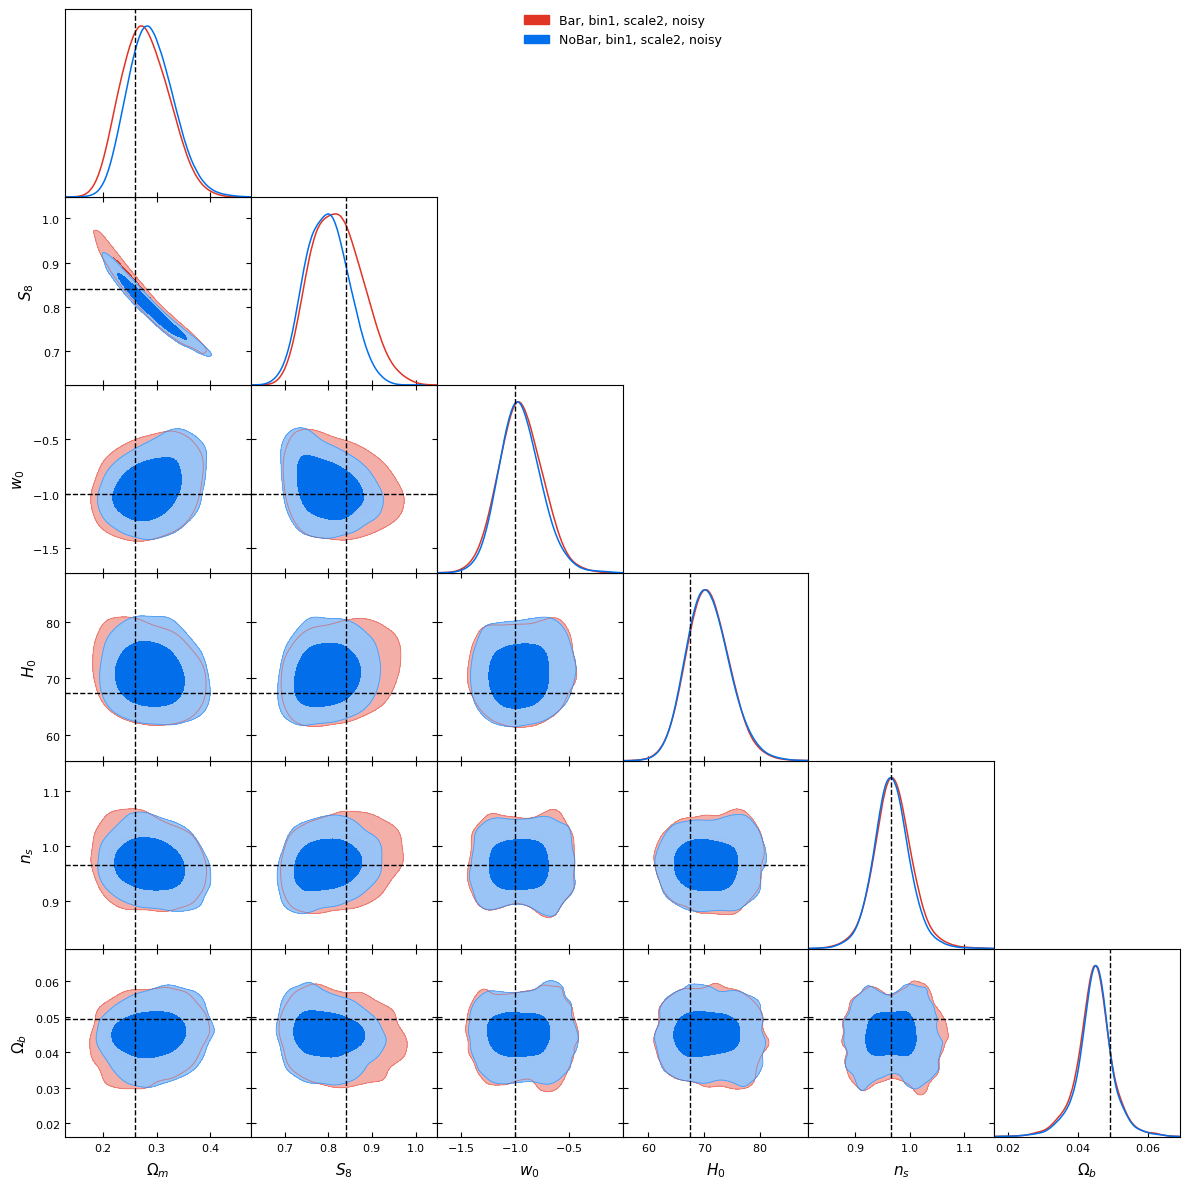

In [ ]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_bar, samples_nobar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_vs_NoBar_bin1_scale1_npe.pdf")
plt.show()